In [1]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torch.utils import data
import matplotlib.pyplot as plt
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

train_data = datasets.MNIST(
    root = 'data',
    train = True,                         
    transform = ToTensor(),  # check difference with and without transform
    download = False,            
)
test_data = datasets.MNIST(
    root = 'data', 
    train = False, 
    transform = ToTensor()
)

train_data=data.Subset(train_data, range(60000))
train_loader=DataLoader(train_data, batch_size=100, shuffle=True)
#for  X_train, y_train in train_loader:
#    X_train, y_train = X_train.to(device), y_train.to(device)

test_data=data.Subset(test_data, range(10000))
test_loader=DataLoader(test_data, batch_size=100, shuffle=True)

cuda


In [2]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(      #    [batch, 1, 28, 28] -> [batch, 16, 14, 14]
            nn.Conv2d(
                in_channels=1,  # greyscale image            
                out_channels=16,   # use 16 kernels        
                kernel_size=5,     # k=5         
                stride=1,           # s=1        
                padding=2,          #  p=2       
            ),                       # [batch, 1, 28, 28] -> [batch, 16, (28+2*2-5)/1+1=28, 28]       
            nn.ReLU(),               # [batch, 16, 28, 28] -> [batch, 16, 28, 28]       
            nn.MaxPool2d(kernel_size=2),  #  [batch, 16, 28, 28] -> [batch, 16, 28/2=14, 14]
        )
        self.conv2 = nn.Sequential(         # [batch, 16, 14, 14] -> [batch, 32, 7, 7]
            nn.Conv2d(16, 32, 5, 1, 2),     # [batch, 16, 14, 14] -> [batch, 32, (14+2*2-5)/1+1=14, 14]
            nn.ReLU(),               #  [batch, 32, 14, 14] -> [batch, 32, 14, 14]       
            nn.MaxPool2d(2),         #  [batch, 32, 14, 14] -> [batch, 32, 14/2=7, 7]    
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10) # [batch, 32 * 7 * 7] -> [batch, 10]
    def forward(self, x): # x: [batch, 1, 28, 28]
        x = self.conv1(x) # [batch, 1, 28, 28] -> [batch, 16, 14, 14]
        x = self.conv2(x) # [batch, 16, 14, 14] -> [batch, 32, 7, 7]
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       # x.size(0) is the batch size, [batch, 32, 7, 7] -> [batch, 32*7*7]
        output = self.out(x)
        return output

model = CNN()
model = torch.load("./gan_mnist_best.model", weights_only=False)
model = model.to(device)
model.eval()
print(model)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


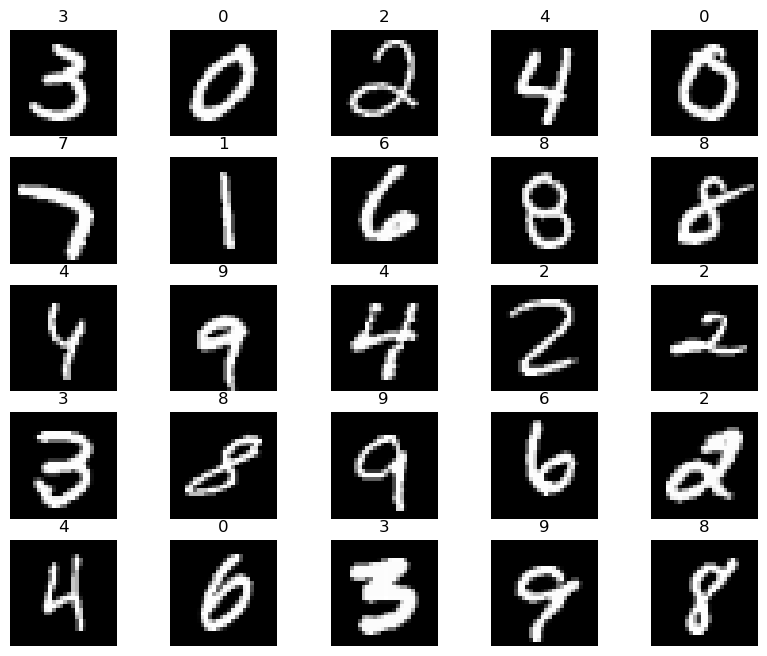

In [11]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img = test_data[sample_idx][0]
    figure.add_subplot(rows, cols, i)
    img_gpu = img.to(device)
    img_gpu = torch.unsqueeze(img_gpu, 0) # add a new dimension [1, 28, 28] -> [1, 1, 28, 28]
    yhat = model(img_gpu) # [batch, 1, 28, 28] input should be [1, 1, 28, 28]
    #print(yhat)
    #print(yhat)
    label_hat = torch.argmax(yhat) # predicted label
    #print(label_hat)
    #img = img.to(device)
    plt.title(label_hat.data.item())
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


In [12]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names
print(model)
return_nodes = {
    "conv1": "layer0", # rename as layer1
    "conv2": "layer1" # rename as layer1
}
model2 = create_feature_extractor(model, return_nodes=return_nodes)
print(model2)


CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)
CNN(
  (conv1): Module(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Module(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)



def forward(self, x):
    conv1_0 = getattr(self.conv1, "0")(x);  x = None
    conv1_1 = getattr(self.conv1, "1")(conv1_0);

torch.Size([100, 16, 14, 14])


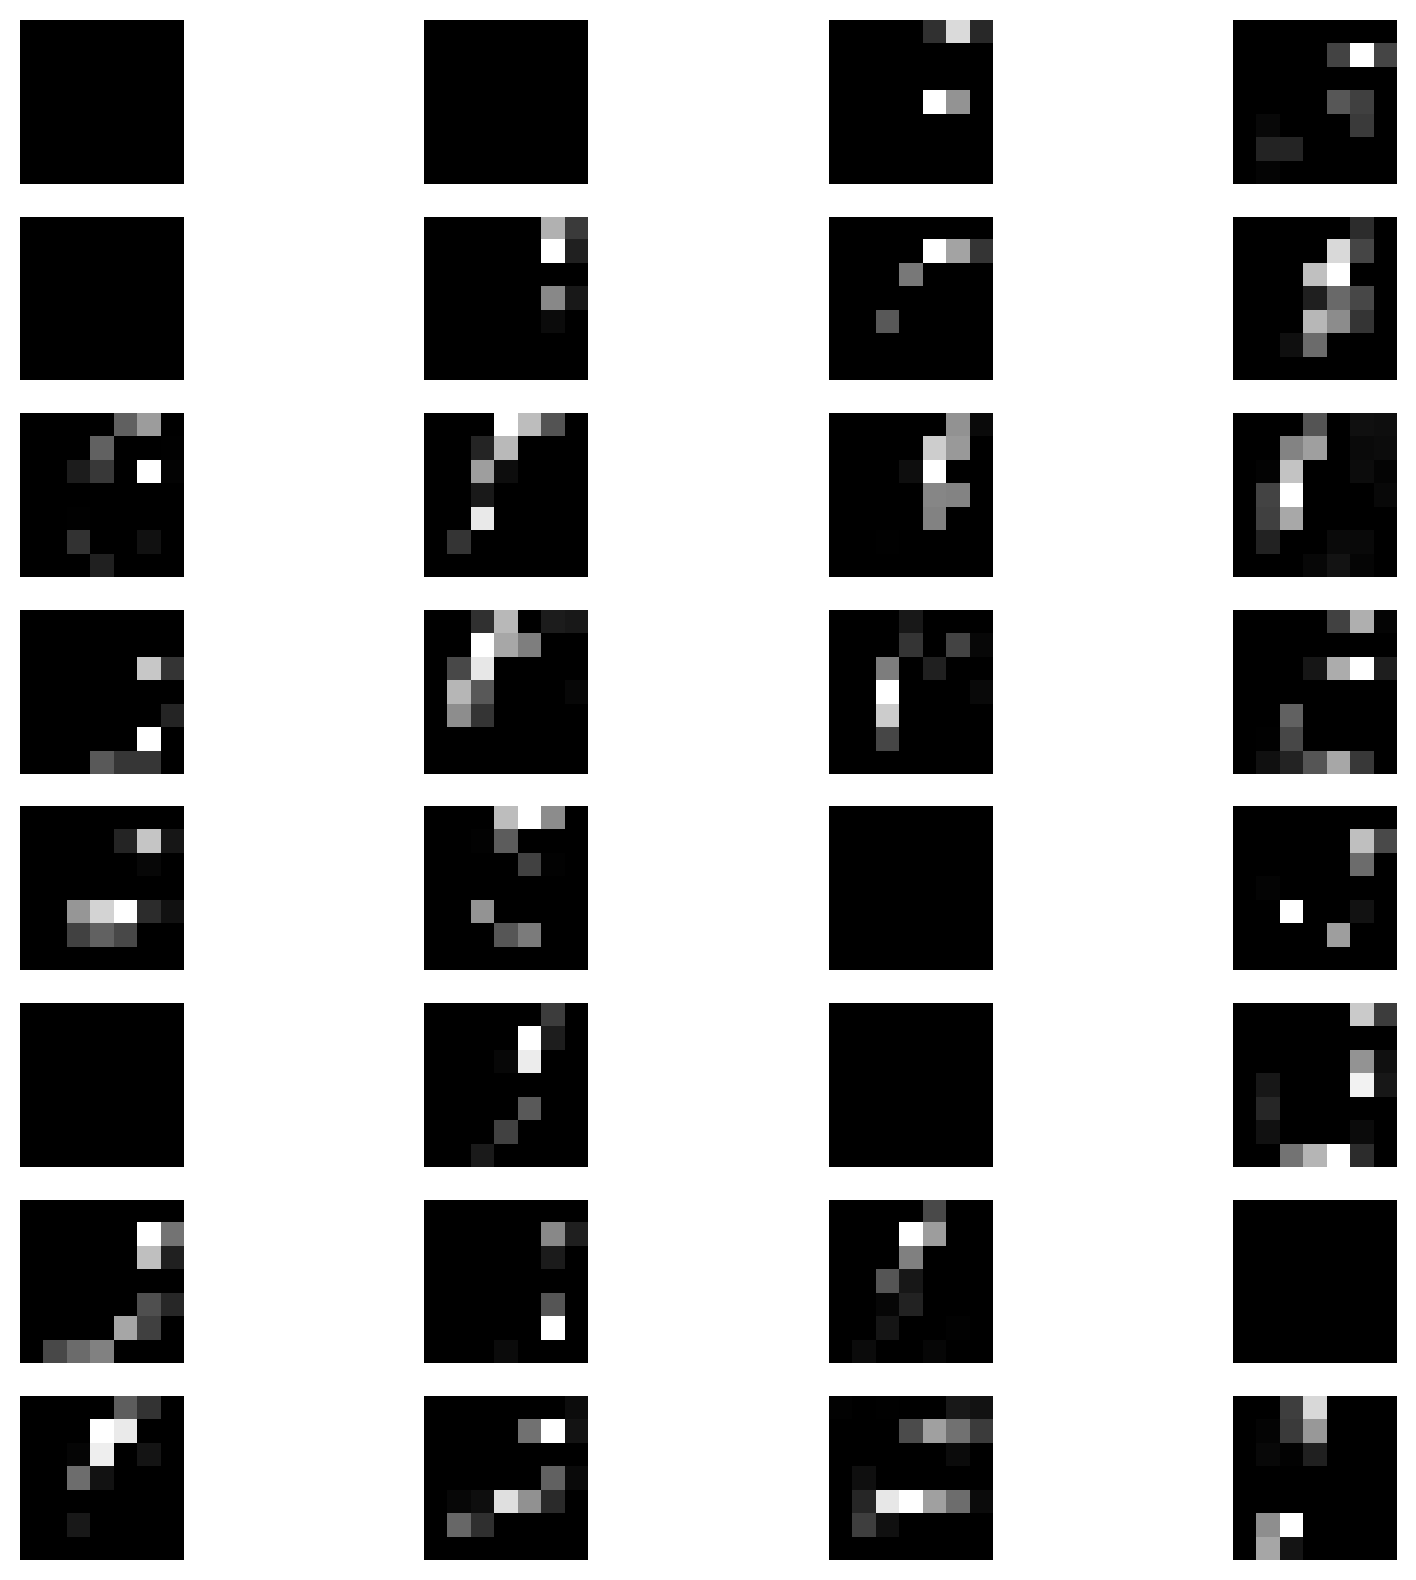

In [13]:
#for  X_test, y_test in test_loader:
#    break
X_test, y_test = next(iter(test_loader))
X_test = X_test.to(device)
intermediate_outputs = model2(X_test)
print(intermediate_outputs['layer0'].shape)

figure = plt.figure(figsize=(10, 10), dpi=200)
cols, rows = 4, 8
for i in range(1, cols * rows + 1):
    img = intermediate_outputs['layer1'][1][i-1]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.cpu().squeeze().detach().numpy(), cmap='gray')
plt.show()




In [14]:
intermediate_outputs

{'layer0': tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.1542, 0.1146, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.5302, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.2553, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0891, 0.0959, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.7116, 1.0334, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.3798, 0.9903, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0415, 0.0415, 0.0415,  ..., 0.0415, 0.0415, 0.0415],
           [0.0415, 0.0415, 0.0415,  ..., 0.0000, 0.0000, 0.0415],
           [0.